# Random Forest — Final Model

This notebook documents the final Random Forest iteration selected for the project.

The workflow evaluates the model on the selected feature set, compares training and test performance, analyses learning curves and assesses the final classification performance.

> **Data availability:** The original project datasets are not included in this public repository. Place the processed input files in `../data/` using the filenames referenced below.


## Load and Merge Product and Store Data


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
from pathlib import Path

DATA_DIR = Path("../data")

df1 = pd.read_excel(DATA_DIR / "products_ML.xlsx")
df2 = pd.read_excel(DATA_DIR / "cleaned_store.xlsx")


In [ ]:
df = pd.merge(df1, df2, on='idstore', how='left')

## Model Development


In [ ]:
df['is_brand_2'] = (df['brand'] == 2).astype(int)
display(df[['brand', 'is_brand_2']].head())

,brand,is_brand_2
0,2,1
1,7,0
2,7,0
3,7,0
4,7,0


In [ ]:
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.inspection import permutation_importance

# =========================================================
# STEP 1: Split do Dataset
# =========================================================
train_raw, test_raw = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df['sold']
)

print(f"Training rows: {len(train_raw)} | Testing rows: {len(test_raw)}")
# =========================================================
# STEP 2: Criar algumas features adicionais
# =========================================================
def engineer_features(train_df, eval_df=None):
    """
    Applies feature engineering cleanly.
    Statistics (e.g. store inventory counts) are computed STRICTLY on train_df
    and mapped onto train_df and optional eval_df (val or test).
    """
    train_df = train_df.copy()

    splits = [train_df]
    if eval_df is not None:
        eval_df = eval_df.copy()
        splits.append(eval_df)

    # 1. Labelling ao fim de semana
    for df_split in splits:
        df_split['labelling_day_of_week'] = df_split['labelling_date'].dt.dayofweek
        df_split['is_weekend_labelling'] = (df_split['labelling_day_of_week'] >= 5).astype(int)


    if eval_df is not None:
        return train_df, eval_df
    return train_df


train_processed, test_processed = engineer_features(train_raw, test_raw)

# Lista das feature que vamos usar
features = [
    'discount', 'Margin (%)', 'Profit (€)', 'new_pvp',

    'days_until_expiration', 'is_weekend_labelling',

    'selling_square_ft', 'is_brand_2'
]



X_train = train_processed[features]
y_train = train_processed['sold']

X_test = test_processed[features]
y_test = test_processed['sold']

# =========================================================
# STEP 4 - LIGHTWEIGHT RANDOMIZED SEARCH
# =========================================================
print("\n" + "="*50)
print("STAGE 1: RANDOMIZED SEARCH (MEMORY-SAFE)")
print("="*50)

param_dist = {
    'n_estimators': [100, 200, 500],
    'min_samples_leaf': [10, 20],
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=2)

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=10,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

best_random_params = random_search.best_params_
print(f"Melhores Parametros Randomized Search:\n{best_random_params}")



Training rows: 119995 | Testing rows: 29999

STAGE 1: RANDOMIZED SEARCH (MEMORY-SAFE)


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best parameters from Randomized Search:
{'n_estimators': 500, 'min_samples_leaf': 10}

STAGE 2: GRID SEARCH (FOCUSED & LIGHTWEIGHT)


In [ ]:

param_dist = {
    'n_estimators': [ 450, 500, 550],
    'min_samples_leaf': [8, 10, 12],

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_dist,
    scoring='roc_auc',
    cv=3,
    n_jobs=2
)

grid_search.fit(X_train, y_train)

final_rf_model = grid_search.best_estimator_
print(f"Melhores parametros Grid Search:\n{grid_search.best_params_}")


# =========================================================
# STEP 5: Avaliacao
# =========================================================
y_pred = final_rf_model.predict(X_test)
y_proba = final_rf_model.predict_proba(X_test)[:, 1]

print("\n=== CLASSIFICATION REPORT (TEST SET) ===")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}\n")



/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters after Grid Search:
{'min_samples_leaf': 8, 'n_estimators': 500}

=== CLASSIFICATION REPORT (TEST SET) ===
              precision    recall  f1-score   support

           0       0.68      0.63      0.65     13902
           1       0.70      0.75      0.72     16097

    accuracy                           0.69     29999
   macro avg       0.69      0.69      0.69     29999
weighted avg       0.69      0.69      0.69     29999

ROC-AUC Score: 0.7588



## Model Evaluation


We compared the test-set results with the training set to assess model stability. In this iteration, there was an approximately 4% gap across the evaluation metrics, which could indicate some overfitting.


In [ ]:
y_train_pred = final_rf_model.predict(X_train)
y_train_proba = final_rf_model.predict_proba(X_train)[:, 1]

print("\n=== CLASSIFICATION REPORT (TRAIN SET) ===")
print(classification_report(y_train, y_train_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_train, y_train_proba):.4f}\n")




=== CLASSIFICATION REPORT (TRAIN SET) ===
              precision    recall  f1-score   support

           0       0.73      0.66      0.69     55610
           1       0.73      0.79      0.76     64385

    accuracy                           0.73    119995
   macro avg       0.73      0.72      0.73    119995
weighted avg       0.73      0.73      0.73    119995

ROC-AUC Score: 0.8101



To investigate model behaviour further, we plotted the learning curves.


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


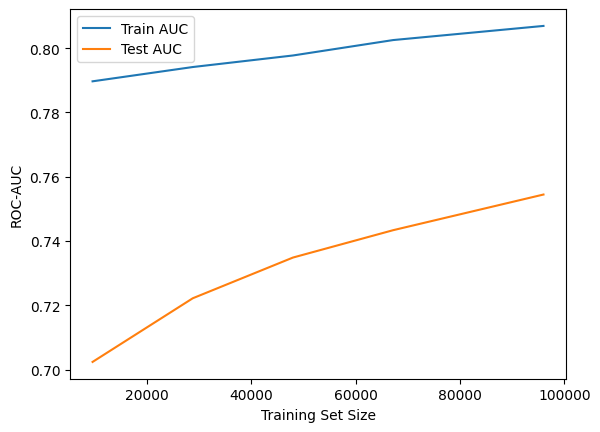

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    estimator=final_rf_model, X=X_train, y=y_train, cv=5, scoring='roc_auc',
    train_sizes=[0.1, 0.3, 0.5, 0.7, 1.0], n_jobs=2
)

# Plotting the mean scores
plt.plot(train_sizes, train_scores.mean(axis=1), label='Train AUC')
plt.plot(train_sizes, test_scores.mean(axis=1), label='Test AUC')
plt.xlabel('Training Set Size')
plt.ylabel('ROC-AUC')
plt.legend()
plt.show()

The learning curves showed that the gap remained at the end of the available dataset but decreased as the training set grew. We considered this a positive result and an indication that additional data could potentially improve performance.


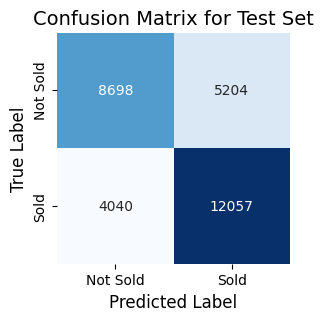

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plotting the confusion matrix
plt.figure(figsize=(3, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Sold', 'Sold'], yticklabels=['Not Sold', 'Sold'])
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix for Test Set', fontsize=14)
plt.show()

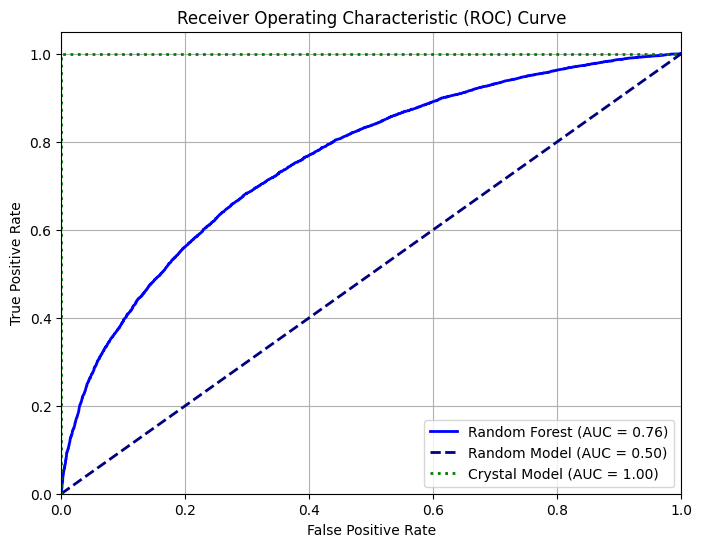

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curve for the Random Forest model
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_proba)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))

# Plot the Random Forest ROC curve
plt.plot(fpr_rf, tpr_rf, color='blue', lw=2, label=f'Random Forest (AUC = {auc_rf:.2f})')

# Plot the random model (diagonal line)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Model (AUC = 0.50)')

# Plot the "crystal" (perfect) model
plt.plot([0, 0, 1], [0, 1, 1], color='green', lw=2, linestyle=':', label='Crystal Model (AUC = 1.00)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## Conclusion


This was our best Random Forest model. Before selecting it, we evaluated another algorithm to determine whether it could provide better performance. The comparison is documented in the XGBoost notebook.


XGBoost did not provide a better result, so we selected the final Random Forest model for the project.
